# What drives math exam scores?

1,000 students' math, reading and writing scores, with gender, ethnic group, parental education, lunch type
(standard vs free/reduced, a proxy for family income) and test-preparation status.

**Note:** this is a fictional teaching dataset, so the findings illustrate the method rather than describe real schools.

**Two questions:**
1. **Early warning:** how much of a student's math score can be predicted from background alone, before any exam?
2. **Drivers:** which factors matter, and by how many points?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import student_model as sm

pd.set_option("display.float_format", "{:.3f}".format)
df = sm.load_data()
print(df.shape, "| missing:", int(df.isna().sum().sum()), "| duplicates:", int(df.duplicated().sum()))
df.head()

(1000, 8) | missing: 0 | duplicates: 0


,gender,ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group D,some college,standard,completed,59,70,78
1,male,group D,associate's degree,standard,none,96,93,87
2,female,group D,some college,free/reduced,none,57,76,77
3,male,group B,some college,free/reduced,none,70,70,63
4,female,group D,associate's degree,standard,none,83,85,86


## 1. Exploratory analysis

,math score,reading score,writing score
math score,1.000,0.812,0.790
reading score,0.812,1.000,0.949
writing score,0.790,0.949,1.000


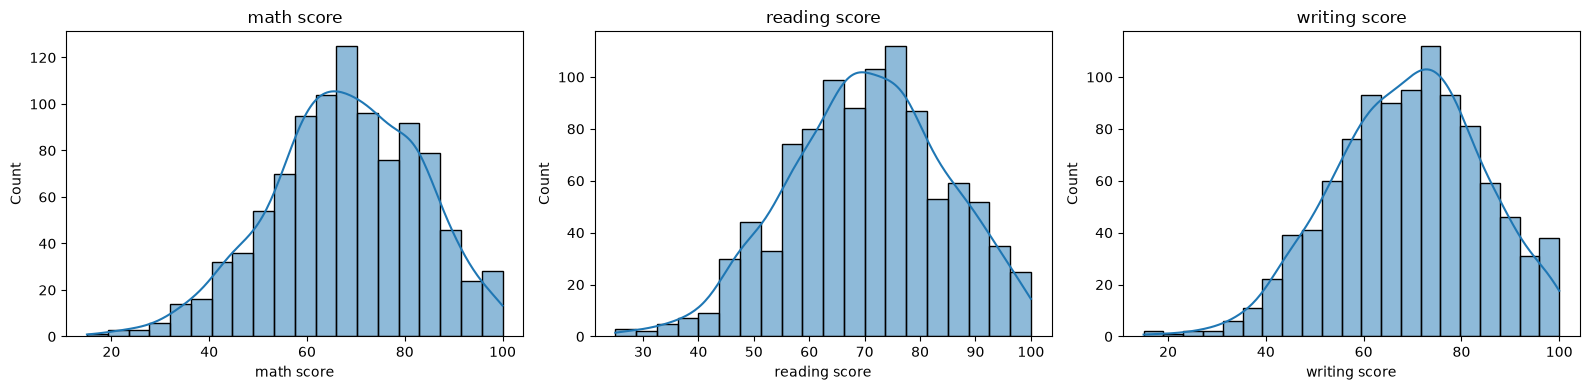

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ["math score", "reading score", "writing score"]):
    sns.histplot(df[col], kde=True, ax=ax); ax.set_title(col)
plt.tight_layout()
df[["math score", "reading score", "writing score"]].corr()

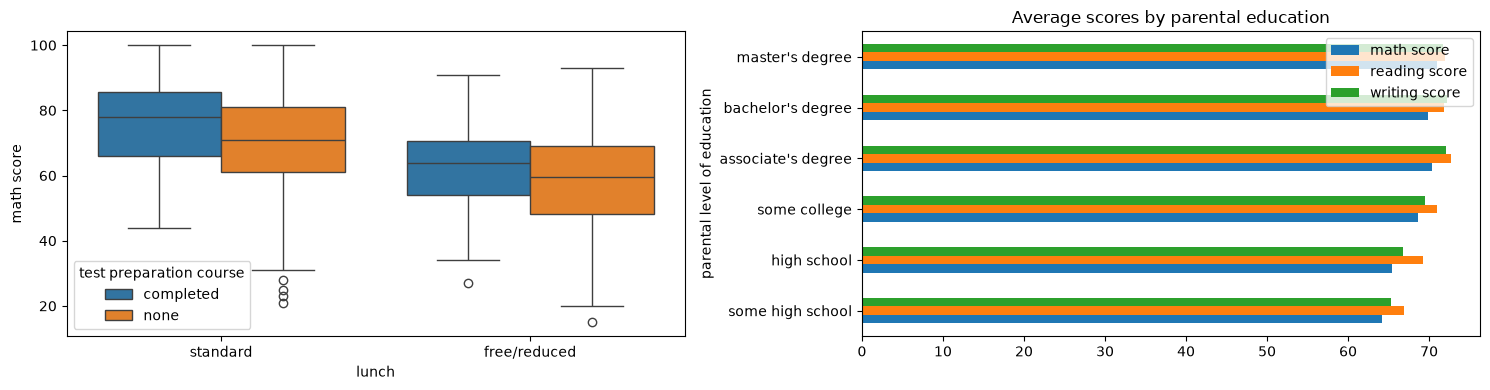

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
sns.boxplot(data=df, x="lunch", y="math score", hue="test preparation course", ax=axes[0])
means = df.groupby("parental level of education")[["math score", "reading score", "writing score"]].mean()
means.reindex(sm.EDUCATION_ORDER).plot.barh(ax=axes[1], title="Average scores by parental education")
plt.tight_layout()

In [4]:
df.groupby("gender")[["math score", "reading score", "writing score"]].mean()

,math score,reading score,writing score
gender,,,
female,64.774,73.474,73.439
male,70.750,67.388,64.976


The three scores are strongly correlated (r ≈ 0.8–0.95). Standard lunch and completed test preparation go with higher
scores. Male students score higher in math and lower in reading and writing.

## 2. How predictable is the math score? (5-fold CV)

In [5]:
sm.cross_validate_models(df)

,MAE,RMSE,R2
Baseline (predict the mean),12.268,15.248,-0.004
Linear regression: Background only,10.349,12.834,0.287
Linear regression: Background + reading/writing,4.376,5.430,0.872


- **Background only:** R² ≈ 0.29, MAE ≈ 10 points. That's useful for flagging students who may need support early, but it
  leaves most of the variation unexplained.
- **With reading and writing:** R² ≈ 0.87, MAE ≈ 4 points. That's easy, because the three scores move together. It's useful for
  spotting an unexpectedly low math score, but not as an early-warning tool.

## 3. Size of each factor

Reference groups: {'gender': 'female', 'ethnicity': 'group A', 'parental level of education': "associate's degree", 'lunch': 'free/reduced', 'test preparation course': 'completed'}


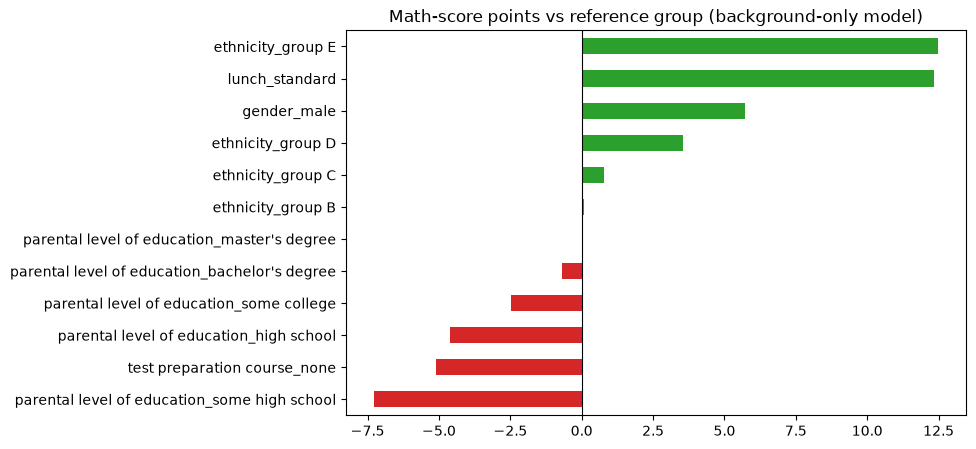

,points
parental level of education_some high school,-7.264
test preparation course_none,-5.092
parental level of education_high school,-4.606
parental level of education_some college,-2.460
parental level of education_bachelor's degree,-0.684
parental level of education_master's degree,0.010
ethnicity_group B,0.090
ethnicity_group C,0.792
ethnicity_group D,3.556
gender_male,5.734


In [6]:
models = sm.fit_models(df)
effects = sm.background_effects(models["Background only"])
print("Reference groups:", sm.reference_groups(models["Background only"]))
effects.plot.barh(figsize=(8, 5), color=["#d62728" if v < 0 else "#2ca02c" for v in effects],
                  title="Math-score points vs reference group (background-only model)")
plt.axvline(0, color="black", lw=0.8)
plt.show()
effects.to_frame("points")

## 4. Conclusions

- **Lunch type** (family income) is worth about **+12 points** for standard lunch, the same size as the largest ethnic-group gap (group E vs group A).
- **Test preparation** is worth about **5 points**. Unlike background, it's something a school can act on.
- **Parental education** shows a gradient: *some high school* is about 7 points below the associate's-degree group.
- Background explains less than a third of the variation. Most of the difference between students comes from factors not in the data.

**Limitations:** the data is fictional and observational. The coefficients are associations, not causal effects.